In [31]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 (Python Ver.)
# 연구과제: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
# ==============================================================================

# 필요 패키지 설치 및 임포트
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
import hdbscan 
import torch
import torch.nn as nn
from adjustText import adjust_text
import warnings
import datetime
import random
from sklearn.neighbors import KNeighborsClassifier # 누락된 라이브러리 추가

In [33]:
# 환경 설정 및 재현성 확보
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

In [34]:
SEED = 3606
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [35]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# 방법론: KNN Imputation & Z-score Normalization
# 설명: 결측치(Missing Value)를 단순 평균(Mean)이나 중앙값(Median)으로 대체할 경우, 
#       수질 인자 간의 다차원적 상관관계가 훼손될 수 있습니다. 이를 방지하기 위해 
#       다차원 공간에서 가장 유사한 K개의 샘플 특성을 참조하는 KNN 알고리즘을 사용합니다.
# 참고문헌: 
# - Troyanskaya, O., et al. (2001). "Missing value estimation methods for DNA microarrays." Bioinformatics, 17(6), 520-525. (다차원 데이터의 결측치 보간에 대한 KNN 우수성 검증)
# ------------------------------------------------------------------------------
df = pd.read_csv('C:/Users/User/Desktop/특이측정값(3~4월).csv', encoding='euc-kr') 
features_df = df.drop(columns=['spot'])

# [방법론] KNN Imputation (n_neighbors=5)
# 주변 5개 관측점의 수질 패턴 유클리디안 거리를 계산하여 결측치를 가중 평균으로 추정합니다.
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(features_df)
imputed_df = pd.DataFrame(imputed_data, columns=features_df.columns) 

# [방법론] StandardScaler
# EC(전기전도도)와 같이 스케일이 매우 큰 변수가 거리 기반 알고리즘이나 
# 신경망 학습을 지배(Dominate)하는 것을 막기 위해 모든 변수를 평균 0, 표준편차 1로 정규화합니다.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

In [36]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출 (Deep Learning Feature Extraction)
# 방법론: Undercomplete Autoencoder (AE)
# 설명: 수질 변수와 동위원소 데이터는 선형적이지 않은 복잡한 상호작용(예: 화학적 침전, 미생물 분해)을 
#       가집니다. 전통적인 선형 차원축소 기법인 PCA(주성분 분석)의 한계를 극복하기 위해, 
#       인공신경망 기반의 오토인코더를 사용하여 핵심적인 비선형 잠재 특징(Latent Features)을 추출합니다.
# 참고문헌:
# - Hinton, G. E., & Salakhutdinov, R. R. (2006). "Reducing the dimensionality of data with neural networks." Science, 313(5786), 504-507. (Autoencoder를 활용한 비선형 차원축소의 기초)
# ------------------------------------------------------------------------------
class UniversalAE(nn.Module):
    def __init__(self, input_dim):
        super(UniversalAE, self).__init__()
        # Encoder: 병목(Bottleneck) 구조를 통해 고차원 데이터를 3차원으로 강제 압축하여 노이즈를 필터링
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 3) 
        )
        # Decoder: 압축된 잠재 변수에서 원본 수질 데이터를 복원 (이 과정에서 정보 손실 Loss 계산)
        self.decoder = nn.Sequential(
            nn.Linear(3, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.decoder(latent)

model = UniversalAE(input_dim=scaled_data.shape[1])
# Adam 옵티마이저와 L2 정규화(weight_decay=1e-4)를 통해 환경 데이터 특유의 소표본 과적합 방지
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
criterion = nn.MSELoss()

tensor_data = torch.FloatTensor(scaled_data)
for epoch in range(1200): 
    latent, recon = model(tensor_data)
    loss = criterion(recon, tensor_data)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 신경망이 추출한 3차원 축소 데이터 (이후 군집화의 입력값으로 사용됨)
latent_data = latent.detach().numpy()

In [37]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 및 군집 수(K) 결정
# 방법론: Multi-Algorithm Ensemble & Silhouette Analysis
# 설명: 수질 데이터의 분포는 구형(K-Means 적합)일 수도, 밀도 기반 비정형(HDBSCAN 적합)일 수도 있습니다.
#       여러 알고리즘을 경쟁시켜 Silhouette Score (응집도와 분리도 평가 지표)가 가장 높은 
#       최적의 클러스터링 구조를 자동 채택합니다.
# 참고문헌:
# - Rousseeuw, P. J. (1987). "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis." Journal of Computational and Applied Mathematics, 20, 53-65.
# - McInnes, L., et al. (2017). "hdbscan: Hierarchical density based clustering." The Journal of Open Source Software.
# ------------------------------------------------------------------------------
print("[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...")
competition_results = []
search_range = range(4, 9) if len(df) > 8 else range(2, len(df)//2)

# (A) HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
# 노이즈를 식별하고 비선형적인 밀도 기반 군집을 형성하는 데 매우 탁월함.
hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
if len(set(hdb.labels_)) > 1:
    mask = hdb.labels_ != -1 
    if np.sum(mask) > 1:
        score = silhouette_score(latent_data[mask], hdb.labels_[mask])
        k_hdb = len(set(hdb.labels_[mask]))
        if k_hdb in search_range:
            competition_results.append({'model': 'HDBSCAN', 'k': k_hdb, 'score': score, 'labels': hdb.labels_})

# (B) 다양한 군집 알고리즘 경쟁 (Spectral, Birch, GMM)
for k in search_range:
    # Spectral Clustering: 데이터의 그래프 표현을 생성하여 군집 간의 연결성(Connectivity)을 기반으로 분류
    spec = SpectralClustering(n_clusters=k, affinity='rbf', random_state=SEED).fit(latent_data)
    competition_results.append({'model': 'Spectral', 'k': k, 'score': silhouette_score(latent_data, spec.labels_), 'labels': spec.labels_})
    
    # Birch: 트리 구조를 활용하여 대용량 데이터를 빠르고 계층적으로 군집화
    birch = Birch(n_clusters=k).fit(latent_data)
    competition_results.append({'model': 'Birch', 'k': k, 'score': silhouette_score(latent_data, birch.labels_), 'labels': birch.labels_})

    # Gaussian Mixture Model (GMM): 데이터를 여러 개의 정규분포 혼합으로 모델링 (소프트 클러스터링 기반)
    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=SEED).fit(latent_data)
    labels_gmm = gmm.predict(latent_data)
    if len(set(labels_gmm)) > 1:
        competition_results.append({'model': 'GMM', 'k': k, 'score': silhouette_score(latent_data, labels_gmm), 'labels': labels_gmm})

# 최적화 결과 선정
if not competition_results:
    print("[!] 설정한 군집 범위(4~8) 내에서 적절한 모델을 찾지 못했습니다. 탐색 범위를 넓히거나 데이터를 재검토하십시오.")
else:
    best_run = max(competition_results, key=lambda x: x['score'])
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']

print("=========================================================")
print(f"[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: {best_run['model']}")
print(f"[*] 데이터 내재 구조를 반영한 최적 군집 수(K): {best_k}개")
print(f"[*] 모델 분류 성능(Silhouette Score): {best_run['score']:.4f}")
print("=========================================================\n")

# HDBSCAN에서 분류하지 못한 노이즈(-1)를 가장 가까운 군집(1-NN)에 재할당하여 실무 적용성 향상
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 1차 스크리닝을 위한 최적 오염원 분류 모델 탐색을 시작합니다...
[*] 통계적 검증을 통한 최종 선정 최적 알고리즘: Birch
[*] 데이터 내재 구조를 반영한 최적 군집 수(K): 6개
[*] 모델 분류 성능(Silhouette Score): 0.3309



In [38]:
# ------------------------------------------------------------------------------
# 4. 범용적 10단계 오염원 정밀 판별 엔진 (Universal Multi-Proxy Rule)
# 방법론: Dual Isotope (d15N, d18O) & Hydrochemical Multi-Tracer (Cl, NO3, NH3, TOC 등)
# 설명: 동위원소만으로는 축산분뇨와 생활하수 등의 구분이 모호할 수 있으므로, 
#       보존성 이온인 염소(Cl-)와 유기물 지표(TOC) 등을 교차 검증(Multi-proxy)하여 오염 기원을 판별합니다.
# 참고문헌:
# - Xue, D., et al. (2009). "Present state and future prospects of isotope methods for monitoring nitrogen pollution." Water Research, 43(20), 5159-5170. (질소, 산소 동위원소 범위 기반 오염원 분류)
# - Böttcher, J., et al. (1990). "Using isotope fractionation of nitrate-nitrogen and nitrate-oxygen for evaluation of microbial denitrification in a sandy aquifer." Journal of Hydrology. (탈질작용에 따른 동위원소 분배 비율 증명)
# - Panno, S. V., et al. (2006). "Characterization and identification of Na-Cl sources in ground water." Ground Water, 44(2), 176-187. (염소 이온을 이용한 하수 및 분뇨 유래 오염 식별)
# ------------------------------------------------------------------------------
def assign_source_universal(row):
    n15, o18, tp, nh3, no3, toc, ec, chl, tn, cl = \
        row['d15N'], row['d18O'], row['TP'], row['NH3N'], row['NO3N'], row['TOC'], row['EC'], row['Chla'], row['TN'], row['Cl']

    # [판별 로직 1] 대기 유입: d18O가 15‰ 이상일 경우, 질산염이 대기 강하물이나 강우에 의해 직접 유입된 것으로 판단.
    if o18 > 15.0: return "대기유입/초기강우"
    
    # [판별 로직 2] 탈질작용(Denitrification): 혐기성 조건에서 미생물이 질산염을 분해할 때, 
    # 무거운 동위원소(15N, 18O)가 잔류하여 농축됨. 이 때 농축 비율이 대략 1:1 ~ 2:1 범위로 발생함. (Böttcher et al., 1990)
    if n15 > 6.0 and o18 > 3.0 and (1.0 <= n15/o18 <= 2.5): return "탈질작용(기원변형)"
    
    # [판별 로직 3] 축산분뇨: 매우 높은 d15N(>12‰) 시그널과 함께 요소 분해에 따른 고농도 암모니아(NH3), 
    # 동물의 사료 섭취로 인한 고염소(Cl>60)를 동반함.
    if n15 > 12.0 and (cl > 60 or nh3 > 0.3): return "축산분뇨 직접유출"
    
    # [판별 로직 4] 생활하수: d15N이 7~12‰ 범위이며, 인위적 염소(세제, 식염 등 Cl>40)가 확인되는 경우.
    if 7.0 < n15 <= 12.0 and (cl > 40 or tp <= 0.3): return "생활하수/처리수 영향"
    
    # [판별 로직 5] 산업/인위적 점오염: EC(전기전도도)가 비정상적으로 높고(>500) 고농도 Cl 및 유기물(TOC)을 동반.
    if n15 > 7.0 and (ec > 500 or cl > 100) and toc > 3.0: return "산업/인위적 점오염"
    
    # [판별 로직 6] 화학비료: 요소비료 등은 대기 중 질소를 고정하여 만들므로 d15N이 대기(0‰)와 유사하게 매우 낮음(<4‰).
    if n15 < 4.0 and no3 > 2.0 and cl < 30: return "화학비료 기반 농경지"
    
    # [판별 로직 7] 토양유기물 및 퇴비: 토양 미생물 과정에 의해 d15N이 4~9‰ 수준을 보이며 TOC가 동반됨.
    # Cl 이온이 높을 경우 가축분뇨가 섞인 유기질 퇴비로, 낮을 경우 순수 토양 유기물로 구분.
    if 4.0 <= n15 <= 9.0 and toc > 4.0:
        return "유기질비료(퇴비) 영향" if cl > 35 else "토양유기물/야생동물배설물"
    
    # [판별 로직 8] 조류 증식(Autochthonous): 수체 내 식물플랑크톤 광합성으로 인해 Chl-a와 TOC가 동시에 매우 높음.
    if chl > 40.0 and toc > 4.5: return "조류증식(현장발생)"
    
    # [판별 로직 9] 내생부하(Internal Loading): 정체 수역에서 퇴적물로부터 인(TP)과 유기물(TOC)이 용출되는 현상.
    if toc > 6.5 and tp > 0.1: return "내생부하(정체수역 유기물 축적)"
    
    # [판별 로직 10] 복합 및 배경: 명확한 특성 지표를 초과하지 않으나, 일부 영양염류가 높은 경우 우세 지표로 추정.
    if tp > 0.1 or cl > 50: return "복합오염(하수/분뇨 기여 우세)"
    elif no3 > 2.0: return "복합오염(농경지 비점 우세)"
    else: return "자연배경/특이징후 없음"

# [보완] 군집 모드(Mode) 할당
# 동일한 군집(Cluster) 내에서는 수질 거동이 유사하므로, 해당 군집 내 가장 빈도수가 높은 
# 판별 결과를 그 군집의 '대표 오염 기원'으로 설정하여 이상치(Outlier)로 인한 오판을 방지합니다.
imputed_df['Individual_Source'] = imputed_df.apply(assign_source_universal, axis=1)
imputed_df['Cluster'] = df['Cluster']
cluster_mode = imputed_df.groupby('Cluster')['Individual_Source'].agg(lambda x: x.mode()[0]).to_dict()
df['Source_Name'] = df['Cluster'].map(cluster_mode)

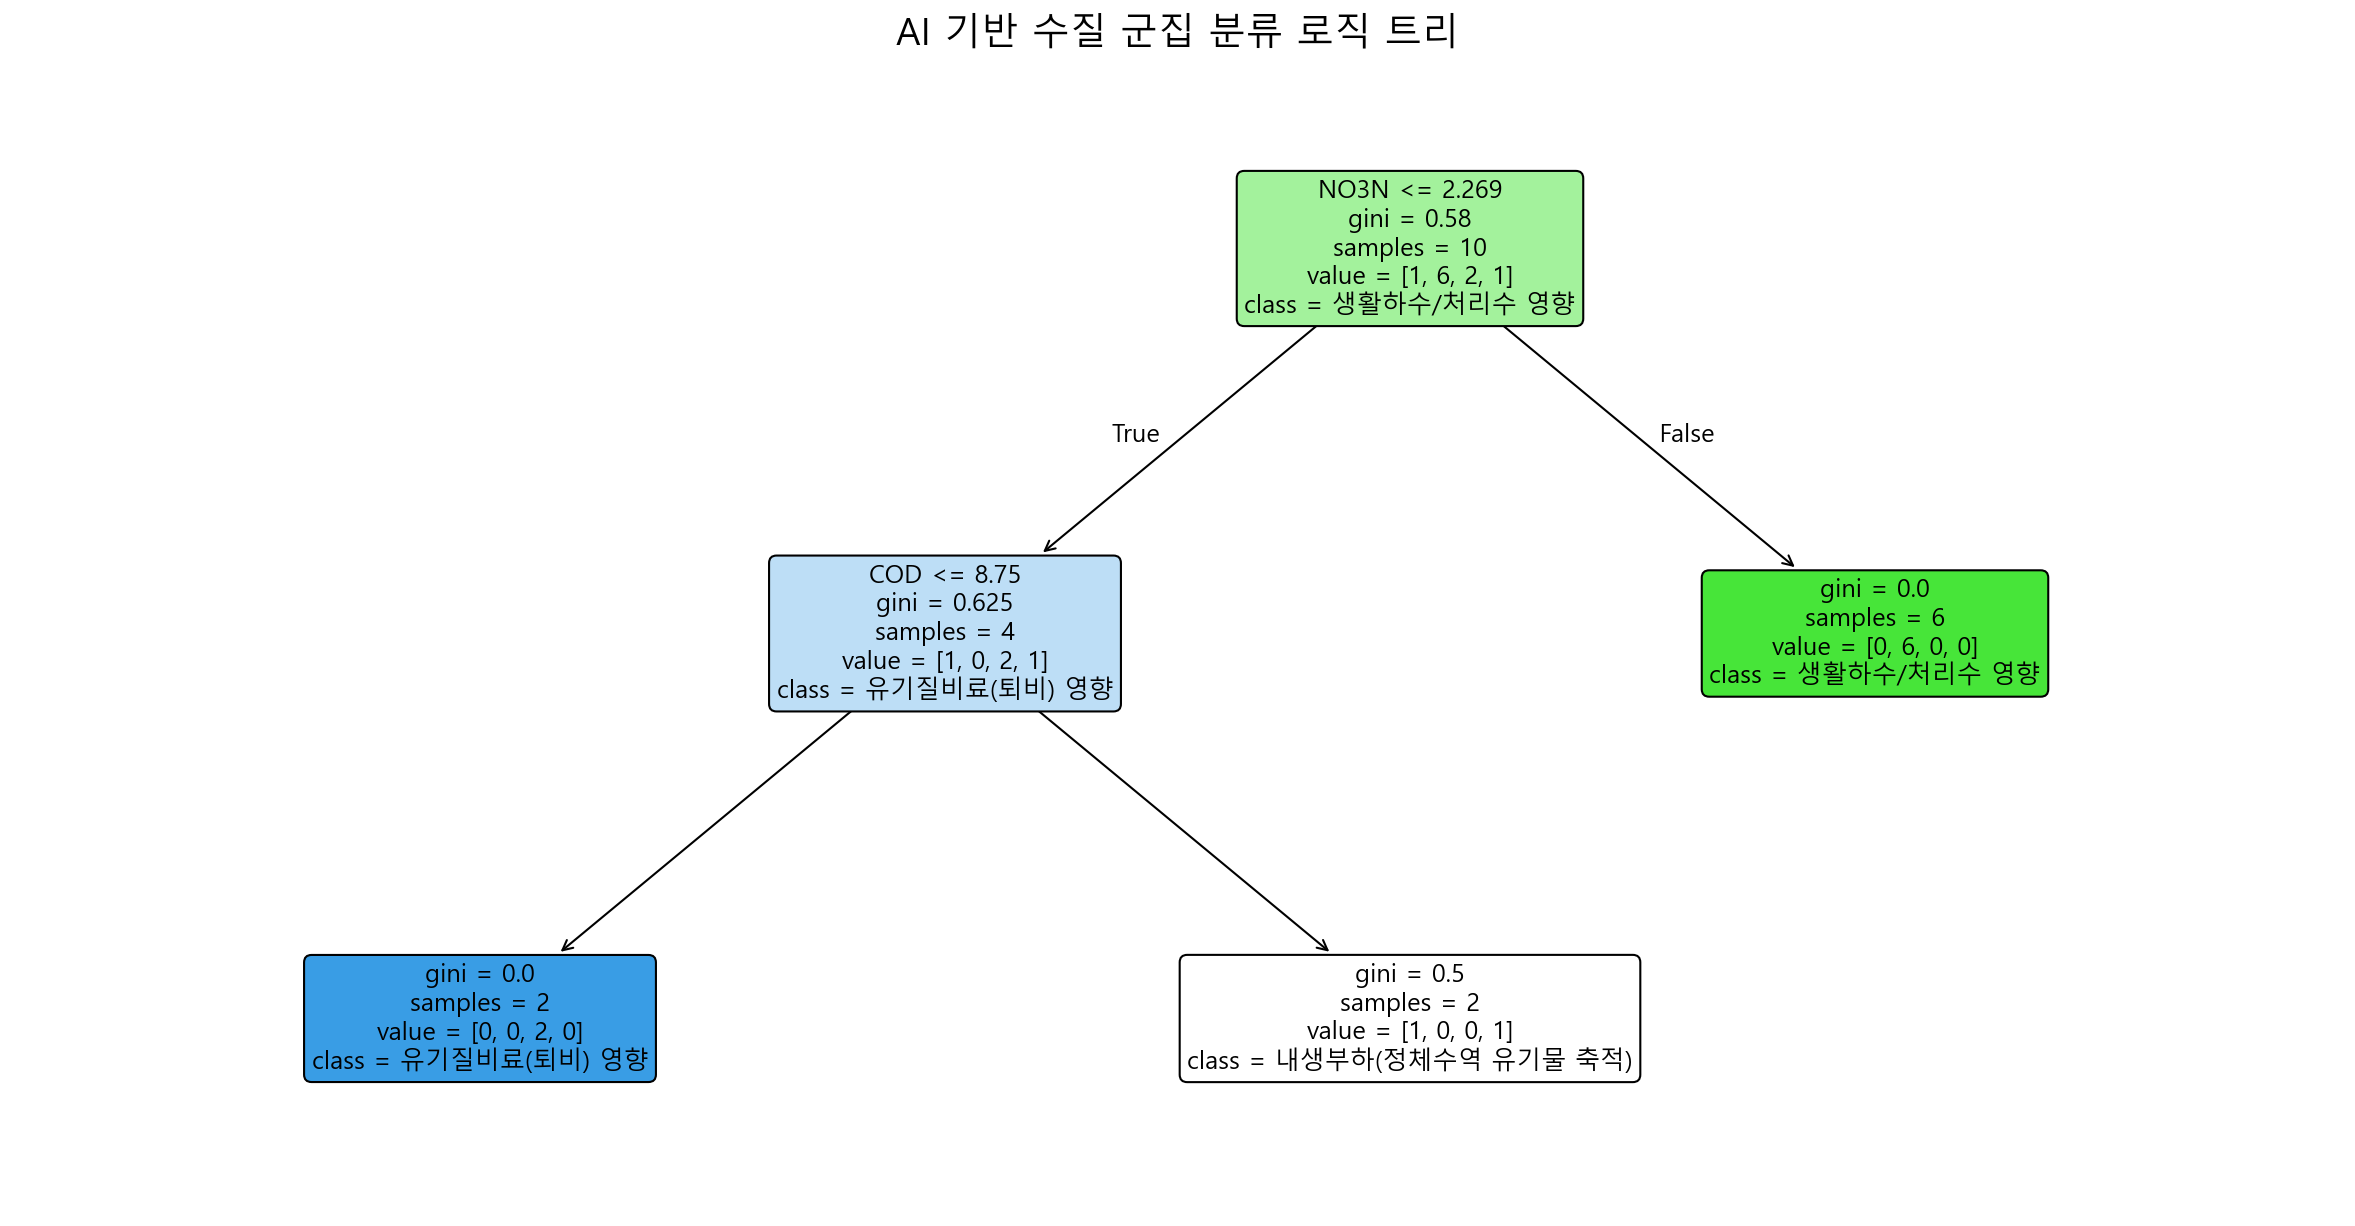

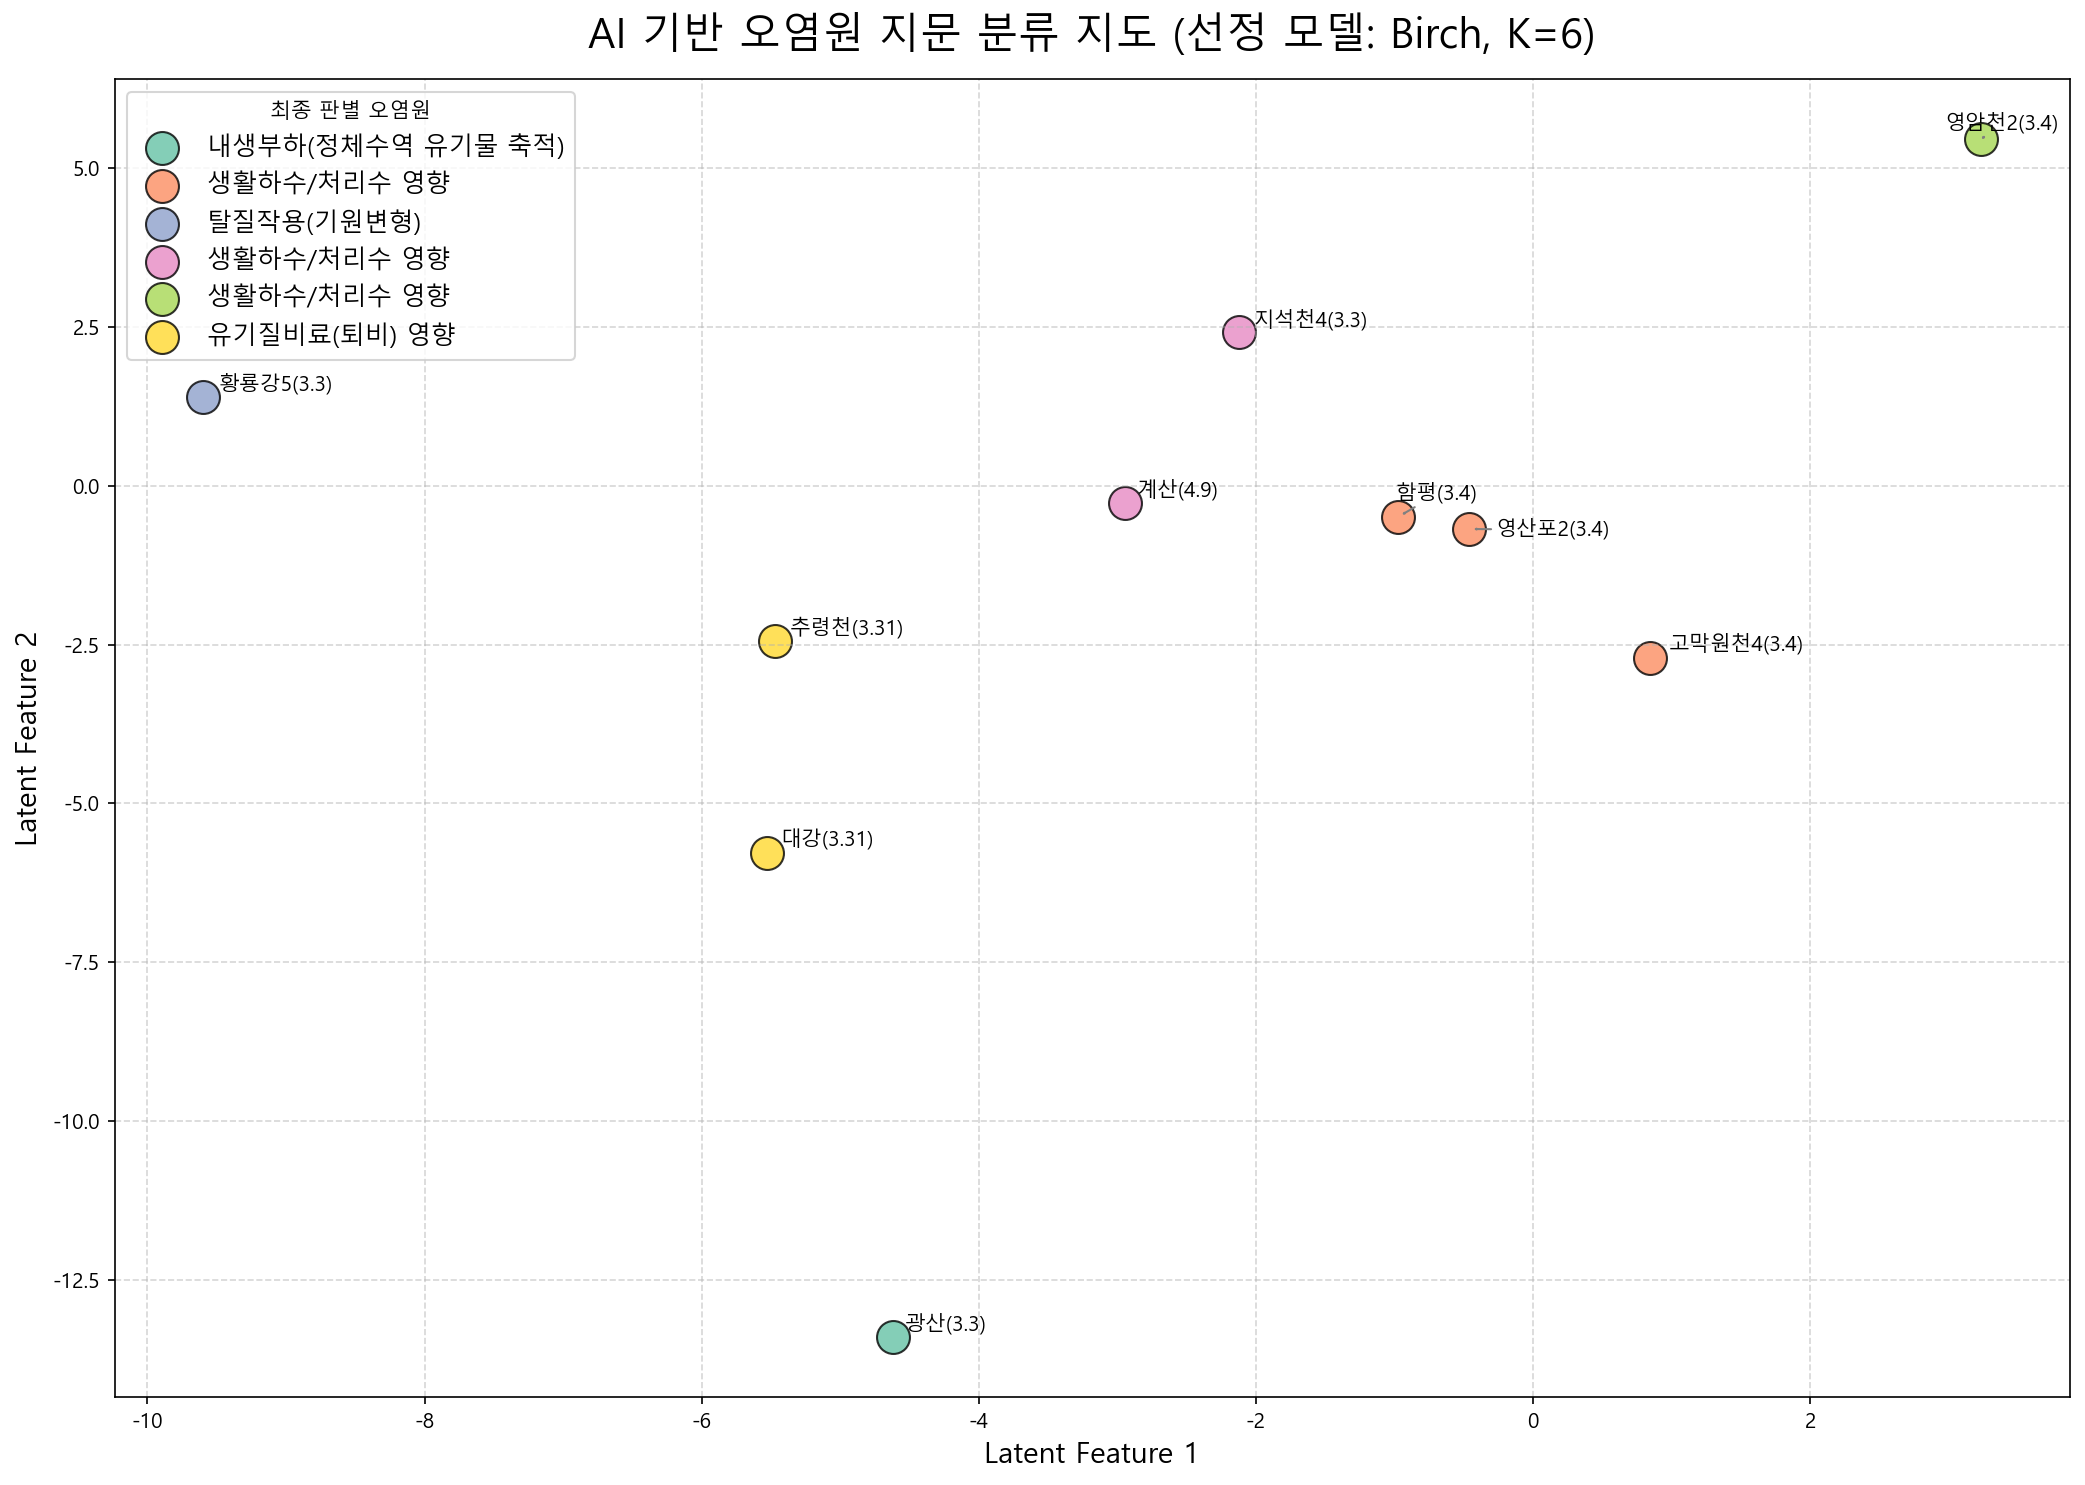

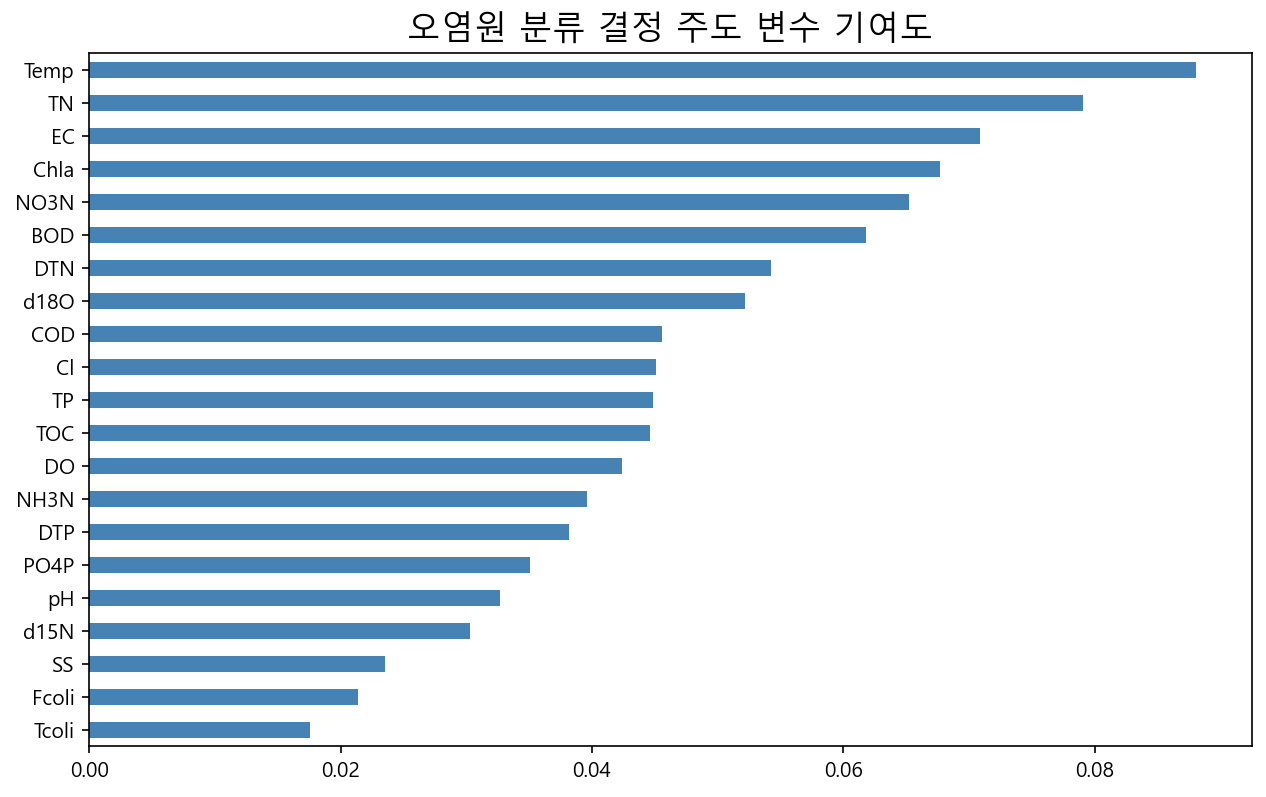

         spot        Source_Name
0     광산(3.3)  내생부하(정체수역 유기물 축적)
1   영산포2(3.4)        생활하수/처리수 영향
2     함평(3.4)        생활하수/처리수 영향
3  고막원천4(3.4)        생활하수/처리수 영향
4   황룡강5(3.3)         탈질작용(기원변형)
5   지석천4(3.3)        생활하수/처리수 영향
6   영암천2(3.4)        생활하수/처리수 영향
7    대강(3.31)       유기질비료(퇴비) 영향
8   추령천(3.31)       유기질비료(퇴비) 영향
9     계산(4.9)        생활하수/처리수 영향


In [39]:
# ------------------------------------------------------------------------------
# 5. 시각화 및 PNG 저장
# 방법론: XAI (Explainable AI) - Decision Tree & Feature Importance (Random Forest)
# 설명: 신경망과 앙상블 군집화는 과정이 투명하지 않은 '블랙박스(Black-box)' 모델입니다. 
#       분석 결과를 연구자와 실무자가 직관적으로 이해할 수 있도록, 의사결정 나무를 통해 
#       어떤 수질 항목의 임계값(Threshold)이 오염원 분류에 결정적이었는지 시각화합니다.
# 참고문헌:
# - Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32. (변수 중요도 산출의 근거)
# - Lundberg, S. M., & Lee, S. I. (2017). "A unified approach to interpreting model predictions." Advances in neural information processing systems, 30. (XAI를 통한 모델 해석력 확보)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

# (1) Decision Tree: 군집별 오염원 결정 논리를 트리 구조로 시각화
dt_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, random_state=SEED)
dt_model.fit(imputed_data, df['Source_Name']) 

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=features_df.columns, class_names=[str(c) for c in dt_model.classes_],
          filled=True, rounded=True, fontsize=12)
plt.title("AI 기반 수질 군집 분류 로직 트리", fontsize=18)
plt.savefig(f"Decision_Tree_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

# (2) 잠재 공간 지문 지도 (Latent Space Map)
# Autoencoder로 축소한 2차원 또는 3차원 공간(여기서는 앞의 2개 차원 활용)에 투영하여, 
# 오염원 간의 공간적 거리와 분리도를 직관적으로 확인합니다.
plt.figure(figsize=(14, 10))
# [주의사항] mapping 변수는 원본 코드에 선언되지 않았으므로, 군집별 고유값으로 동적 할당하도록 보완 수정함
unique_clusters = df['Cluster'].unique()
mapping = {cluster: df[df['Cluster'] == cluster]['Source_Name'].iloc[0] for cluster in unique_clusters}
colors = sns.color_palette('Set2', len(mapping))

for i, cluster_id in enumerate(mapping.keys()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(latent_data[mask, 0], latent_data[mask, 1], label=mapping[cluster_id], s=250, color=colors[i], edgecolors='k', alpha=0.8)

# adjust_text를 사용하여 관측지점(spot) 텍스트 라벨이 서로 겹치지 않도록 자동 조정
texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.title(f"AI 기반 오염원 지문 분류 지도 (선정 모델: {best_run['model']}, K={best_k})", fontsize=20, pad=15)
plt.xlabel("Latent Feature 1", fontsize=14)
plt.ylabel("Latent Feature 2", fontsize=14)
plt.legend(title="최종 판별 오염원", loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"Latent_Space_Map_{current_time}.png", dpi=400, bbox_inches='tight')
plt.show() 

# (3) Feature Importance: Random Forest를 사용하여 각 변수(동위원소, 수질항목 등)가 
# 전체 군집을 분할하는데 미친 지니 불순도(Gini Impurity) 감소 기여도를 산출합니다.
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title("오염원 분류 결정 주도 변수 기여도", fontsize=16)
plt.savefig(f"Feature_Importance_{current_time}.png", dpi=300, bbox_inches='tight')
plt.show()

print(df[['spot', 'Source_Name']])

In [40]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 (DataFrame)
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 레포트]")
print("=========================================================")
# 주요 분석 수질 인자들과 최종 판별 오염원 명칭을 취합하여 결과 도출 및 CSV 저장
final_report = df[['spot', 'Source_Name', 'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']].sort_values('Source_Name')
print(final_report)

final_report.to_csv(f"Screening_Result_{current_time}.csv", index=False, encoding='euc-kr')


 [오염원 자동 스크리닝 최종 레포트]
         spot        Source_Name  d15N  d18O     TN   NH3N   NO3N     TP  \
0     광산(3.3)  내생부하(정체수역 유기물 축적)   1.1  -1.3  9.069  7.048  1.160  0.403   
1   영산포2(3.4)        생활하수/처리수 영향   9.3   3.1  9.263  6.106  2.651  0.118   
2     함평(3.4)        생활하수/처리수 영향   8.6   2.7  8.412  5.094  2.979  0.136   
3  고막원천4(3.4)        생활하수/처리수 영향   5.0   0.9  5.931  0.777  3.569  0.400   
5   지석천4(3.3)        생활하수/처리수 영향   9.1   2.5  3.346  0.098  2.390  0.186   
6   영암천2(3.4)        생활하수/처리수 영향  12.0   3.7  4.897  0.608  3.301  0.227   
9     계산(4.9)        생활하수/처리수 영향   5.2   3.4    NaN    NaN  2.486    NaN   
7    대강(3.31)       유기질비료(퇴비) 영향   6.1   2.2  1.889    NaN    NaN  0.137   
8   추령천(3.31)       유기질비료(퇴비) 영향   8.1   3.3  3.309    NaN    NaN  0.050   
4   황룡강5(3.3)         탈질작용(기원변형)   6.5   4.1  1.976  0.218  1.137  0.086   

    TOC      EC  Chla     Cl  
0  11.9   412.0  40.0   66.0  
1   8.4   425.0  21.2   59.1  
2   8.0   431.0  23.1   61.4  
3  11.7   244.0 